
# EN.605.631 — Assignment 1: Combinatorial Analysis with R

**Submission format:** Jupyter Notebook (`.ipynb`) using the **R kernel**  
**Estimated time:** ~5 hours  
**Total points:** 100

---

## Instructions

- Work in this notebook. For each problem, write your derivations/explanations in Markdown and place your R code in the **empty code cell(s)** provided.  
- At the very top of the notebook, include your environment information and set a fixed seed.  
- Your notebook must run top-to-bottom with **Restart & Run All** in under 2 minutes.
- File name on submission: `lastname_firstname_ch1_combinatorics.ipynb`.

## Required setup (fill in below)
- Show `R.version.string` and `sessionInfo()`
- Set a seed: `set.seed(631)`
- List any additional packages used (base R preferred)


In [1]:
R.version.string

[1] "R version 4.6.1 (2026-06-24 ucrt)"

In [2]:
sessionInfo()

R version 4.6.1 (2026-06-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: America/New_York
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] digest_0.6.39   IRdisplay_1.1   base64enc_0.1-6 fastmap_1.2.0  
 [5] glue_1.8.1      htmltools_0.5.9 repr_1.1.7      lifecycle_1.0.5
 [9] cli_3.6.6       vctrs_0.7.3     pbdZMQ_0.3-14   compiler_4.6.1 
[13] tools_4.6.1     evaluate_1.0.5  pillar_1.11.1   crayon_1.5.3   
[17] rlang_1.3.0     jsonlite_2.0.0  IRkernel_1.3.2  uuid_1.2-2     

In [3]:
set.seed(631)

In [4]:
install.packages("bench")
install.packages("magrittr")
library(bench)

Installing package into 'C:/Users/Shane/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'bench' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Shane\AppData\Local\Temp\Rtmp2B5vQc\downloaded_packages


Installing package into 'C:/Users/Shane/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'magrittr' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Shane\AppData\Local\Temp\Rtmp2B5vQc\downloaded_packages



---
## Problem 1 — The Basic Principle (Product Rule) — 10 pts

1. Using the product rule, compute the theoretical count of license plates with the first 3 positions as letters (A–Z) and the last 4 as digits (0–9) for:  
   (a) **repetition allowed**, and (b) **repetition forbidden** separately for letters and digits. Show your derivations in Markdown and return numeric values in R.

2. Empirically confirm the product rule by **enumerating a reduced case** (e.g., 2 letters then 2 digits) for both (a) and (b). Discuss computational trade-offs.


### 1a)

There are 26 letters for the first 3 positions and 10 digits for the last 4 positions:

$$26 \cdot 26 \cdot 26 \cdot 10 \cdot 10 \cdot 10 \cdot 10$$

$$= 26^3 \cdot 10^4 = 175{,}760{,}000$$

In [5]:
26^3 * 10^4

[1] 175760000

### 1b)

There are 26 letters for position 1, 25 for position 2, 24 for position 3, and 10 digits for position 4, 9 for position 5, 8 for position 6, and 7 for position 7.

$$26 \cdot 25 \cdot 24 \cdot 10 \cdot 9 \cdot 8 \cdot 7$$

$$= 78{,}624{,}000$$

In [6]:
26 * 25 * 24 * 10 * 9 * 8 * 7

[1] 78624000

### 2a)

In [7]:
enumerated_repeated <- expand.grid(L1 = LETTERS, L2 = LETTERS, D1 = 0:9, D2 = 0:9)

head(enumerated_repeated, 5)
tail(enumerated_repeated, 5)

,L1,L2,D1,D2
,<fct>,<fct>,<int>,<int>
1,A,A,0,0
2,B,A,0,0
3,C,A,0,0
4,D,A,0,0
5,E,A,0,0


,L1,L2,D1,D2
,<fct>,<fct>,<int>,<int>
67596,V,Z,9,9
67597,W,Z,9,9
67598,X,Z,9,9
67599,Y,Z,9,9
67600,Z,Z,9,9


Checking that the number of plates matches what we expect analytically:

In [8]:
26 * 26 * 10 * 10

[1] 67600

### 2b)

In [9]:
letter_pairs <- expand.grid(L1 = LETTERS, L2 = LETTERS)
digit_pairs <- expand.grid(D1 = 0:9, D2 = 0:9)

# remove the cases where the letters or digits are the same
letter_pairs <- subset(letter_pairs, L1 != L2)
digit_pairs <- subset(digit_pairs, D1 != D2)

enumerated_nonrepeated <- merge(letter_pairs, digit_pairs)

head(enumerated_nonrepeated, 5)
tail(enumerated_nonrepeated, 5)

,L1,L2,D1,D2
,<fct>,<fct>,<int>,<int>
1,B,A,1,0
2,C,A,1,0
3,D,A,1,0
4,E,A,1,0
5,F,A,1,0


,L1,L2,D1,D2
,<fct>,<fct>,<int>,<int>
58496,U,Z,8,9
58497,V,Z,8,9
58498,W,Z,8,9
58499,X,Z,8,9
58500,Y,Z,8,9


Check that the number of plates matches what we expect analytically:

In [10]:
26 * 25 * 10 * 9

[1] 58500

### Computational Tradeoffs

Enumerating all cases requires explicitly computing all possible combinations. We had to use a reduced case because enumerating all 175,760,000 plates for the original problem would have taken a lot of time and memory. However, enumerating all cases allows us to count all cases and ensure the correct number.


---
## Problem 2 — Permutations (with/without indistinguishables) — 12 pts

1. Implement `perm_count(n)` that returns `n!` using both (i) iterative multiplication and (ii) `gamma(n+1)`. Compare speed and numerical stability for `n = 5, 10, 50`.
2. For the string **"PEPPER"**, compute the number of distinct permutations analytically and confirm by **generating** all unique permutations of a smaller analog (e.g., "PEPE").
3. Bookshelf blocks: implement `block_perm(n_vec)` for block sizes `n1,…,nk` (subjects kept together). Test with a few vectors.


## 1)

In [11]:
perm_count <- function(n) {
    product = 1
    while (n > 1) {
        product = product * n
        n = n - 1
    }
    return(product)
}

perm_count(5)
perm_count(10)
perm_count(50)

[1] 120

[1] 3628800

[1] 3.041409e+64

In [12]:
perm_count_gamma <- function(n) {
    return(gamma(n + 1))
}

perm_count(5)
perm_count(10)
perm_count(50)

[1] 120

[1] 3628800

[1] 3.041409e+64

### Speed Comparison

In [13]:
result <- bench::mark(
  iterative_5  = perm_count(5),
  iterative_10  = perm_count(10),
  iterative_50  = perm_count(50),
  gamma_5 = perm_count_gamma(5),
  gamma_10 = perm_count_gamma(10),
  gamma_50 = perm_count_gamma(50),
  
  iterations = 1000,
  check = FALSE
)

print(result[, c(1, 3, 9)])

# A tibble: 6 × 3
  expression     median total_time
  <bch:expr>   <bch:tm>   <bch:tm>
1 iterative_5     300ns    368.9µs
2 iterative_10    400ns    454.2µs
3 iterative_50    1.3µs     1.47ms
4 gamma_5         300ns    275.9µs
5 gamma_10        300ns      294µs
6 gamma_50        300ns    296.2µs


#### Conclusion:

It is much more efficient in terms of time to use gamma(n + 1), especially as n grows larger.

### Numerical Stability 

In [14]:
for (n in c(5, 10, 50)) {
    print(perm_count(n))
    print(perm_count_gamma(n))
}

[1] 120
[1] 120
[1] 3628800
[1] 3628800
[1] 3.041409e+64
[1] 3.041409e+64


#### Conclusion:

Both iterative perm(n) and gamma(n + 1) produce the same result to the same precision.

## 2)

### Analytical Distinct Permutations

PEPPER has 6 letters, so the total number of permutations is 6!.

However there are 3 Ps and 2 Es, so the number of duplicaiton permutations is 3! * 2!

This means the number of distinct permutations is 6! / (3! * 2!)

In [15]:
factorial(6) / (factorial(3) * factorial(2))

[1] 60

### Enumerate Permutations

In [16]:
perms_total <- expand.grid(
    V1 = c("P", "E"),
    V2 = c("P", "E"),
    V3 = c("P", "E"),
    V4 = c("P", "E")
)

perms_total$word <- sprintf("%s%s%s%s", perms_total$V1, perms_total$V2, perms_total$V3, perms_total$V4)

perms_distinct <- perms_total[rowSums(perms_total[, 1:4] == "P") == 2 & rowSums(perms_total[, 1:4] == "E") == 2,]

perms_distinct$word

[1] "EEPP" "EPEP" "PEEP" "EPPE" "PEPE" "PPEE"

## 3)

If given a vector of block sizes $n = (n_1, n_2, \ldots, n_k),$ then within each block $n_i$, there are $n_i!$ arrangements, and in total, there are $n_1! \cdot n_2! \cdot \ldots \cdot n_k!$ arrangements total. Each block can be arranged in $k$! ways, so the total number of arrangements is:

$$k * (n_1! * n_2! * ... * n_k!)$$

In [17]:
block_perm <- function(n_vec) {
    k <- length(n_vec)
    return(factorial(k) * prod(factorial(n_vec)))
}

#### Tests

In [18]:
block_perm(c(2, 2))
factorial(2) * factorial(2) * factorial(2)

[1] 8

[1] 8

In [19]:
block_perm(c(2, 3))
factorial(2) * factorial(2) * factorial(3)

[1] 24

[1] 24

In [20]:
block_perm(c(2, 2, 4))
factorial(3) * factorial(2) * factorial(2) * factorial(4)

[1] 576

[1] 576


---
## Problem 3 — Combinations & Identities — 14 pts

1. Implement your own `nCr(n, r)` (do not call `choose`). Use a multiplicative form to avoid overflow; validate against `choose` on several `(n, r)`.
2. **Pascal’s identity:** verify numerically that for `n in 2:100` and `r in 1:(n-1)`,
   $$ \binom{n}{r} = \binom{n-1}{r-1} + \binom{n-1}{r} $$
   Report the maximum absolute error in double precision.
3. Provide a concise combinatorial proof (Markdown).


## 1)

In [21]:
nCr <- function(n, r) {
    if (r < 0 || r > n) { return(0) }
    r = min(n - r, r)
    if (r == 0) { return(1) }

    result <- 1
    for (i in 1:r) {
        result <- result * (n - r + i) / i
    }
    return(result)
}

In [22]:
nCr(3, 2)
choose(3, 2)

[1] 3

[1] 3

In [23]:
nCr(4, 2)
choose(4, 2)

[1] 6

[1] 6

In [24]:
nCr(5, 2)
choose(5, 2)

[1] 10

[1] 10

In [25]:
nCr(4, 3)
choose(4, 3)

[1] 4

[1] 4

In [26]:
nCr(4, 4)
choose(4, 4)

[1] 1

[1] 1

In [27]:
nCr(5, 3)
choose(5, 3)

[1] 10

[1] 10

## 2)

In [28]:
max_error <- 0
for (n in 2:100) {
    for (r in 1:(n - 1)) {
        left <- nCr(n, r)
        right <- nCr(n - 1, r - 1) + nCr(n - 1, r)
        abs_error <- abs(left - right)
        if (abs_error > max_error) {
            max_error <- abs_error
            max_error_n <- n
            max_error_r <- r
        }
    }
}

max_error
max_error_n
max_error_r

[1] 3.518437e+13

[1] 100

[1] 47

In [29]:
large_comb <- nCr(100, 47)
large_comb
typeof(large_comb)

[1] 8.441349e+28

[1] "double"

The max absolute error, the greatest difference between the cases of Pascal's Identity for these values is $3.5 \cdot 10^{13}$, which seems massive at first,
but the value of nCr(n, r) when n is huge is many orders of magnitude more massive ($8 * 10^{28}$). This error is because IEEE-754 floating point with
double precision cannot represent numbers this large to the nerest integer, it loses some information when representing it as 64 bits.

## 3)

Choose r items from n options. For item A, there are 2 mutually exclusive cases: 

1) A is chosen, and the remaining r - 1 items must be chosen from teh other n - items -> C(n - 1, r - 1), or
2) A is not chosen, and all r items but be chosen from the remaining n - 1 items -> C(n - 1, r).

Since these cases include every possible group of r items, C(n, r) = C(n - 1, r - 1) + C(n - 1, r).


---
## Problem 4 — Binomial Theorem: Algebra, Code, and Coefficients — 14 pts

1. Expand $(x+y)^n$ for `n=5` by computing the coefficient vector using your `nCr`. Verify that the sum of coefficients equals `2^n` and that coefficients are symmetric.
2. Write `binom_expand(n)` returning a named vector `c_{0:n}` for coefficients of `x^{n-k} y^k`. Confirm by repeated convolution of `(1,1)` with itself `n` times.
3. For `n=30`, analyze the central binomial coefficient versus the Stirling approximation $ \binom{2m}{m} \approx \frac{4^m}{\sqrt{\pi m}} $ with `m=15`. Include a short discussion.


## 1)

Binomial theorem says that $$(x+y)^n = \sum_{k=0}^{n} \binom{n}{k} x^{n-k}y^k$$
Because of the symmetry property of $$\binom{n}{r} = \binom{n}{n-r}$$ this means that $$(x+y)^n = \sum_{k=0}^{n} \binom{n}{k} x^{k}y^{n-k}$$

For $x=1$ and $y=1$, $$(1+1)^n = \sum_{k=0}^{n}\binom{n}{k}(1)^{n-k}(1)^k$$

This means the sum of the coefficients can be determined by $$\sum_{k=0}^{n}\binom{n}{k} = 2^n$$

In [30]:
# coefficients for expanding (x + y)^5 =
coefficient_vector <- c()
for (k in 0:5) {
    coefficient_vector[k + 1] <- nCr(5, k)
}

coefficient_vector

[1]  1  5 10 10  5  1

In [31]:
sum(coefficient_vector)
2^5
all(coefficient_vector == rev(coefficient_vector))

[1] 32

[1] 32

[1] TRUE

## 2)

In [32]:
binom_expand <- function(n) {
    c_ <- c()
    for (k in 0:n) {
        c_[k + 1] <- nCr(n, k)
    }
    return(c_)
}

In [33]:
convolution_coefficients_vector <- c(1)
for (i in 1:5) {
    convolution_coefficients_vector <- convolve(convolution_coefficients_vector, c(1, 1), type="open")
}

convolution_coefficients_vector
binom_expand(5)

[1]  1  5 10 10  5  1

[1]  1  5 10 10  5  1

## 3)

The mth central binomial coefficient, the binomial coefficient located directly in the middle of the even-numbered rows of Pascal's triangle, is: 
$$\binom{2m}{m} = \frac{(2m)!}{(m!)^2}$$

Stirling's approximation is a formula that estimates factorials for large n: 
$$m! \approx \sqrt{2\pi n}\left(\frac{n}{e}\right)^n$$

For the numerator: $$(2m)! \approx \sqrt{2\pi (2m)}\left(\frac{(2m)}{e}\right)^{(2m)} = \sqrt{4\pi m} \left(\frac{2n}{e}\right)^{2m}$$

For the denominator: $$(m!)^2 \approx \left(\sqrt{2\pi m}\left(\frac{m}{e}\right)^m\right)^2 = 2\pi m\left(\frac{m}{e}\right)^{2m}$$

Combine: $$\binom{2m}{m} \approx \frac{(2m)!}{(m!)^2} = \frac{\sqrt{4\pi m} \left(\frac{2m}{e}\right)^{2m}}{2\pi m\left(\frac{m}{e}\right)^{2m}}
 = \frac{2\sqrt{\pi m} \left(\frac{2m}{e}\right)^{2m}}{2\pi m\left(\frac{m}{e}\right)^{2m}}
 = \frac{1}{\sqrt{\pi m}}\left(2^{2m} \right) = \frac{1}{\sqrt{\pi m}}\left(4^m \right) = \frac{4^m}{\sqrt{\pi m}}$$

The nth central binomial coefficient formula, for $n = 30$ gives $\binom{30}{15} = $

In [34]:
bce <- factorial(2 * 15) / (factorial(15)^2)
bce

[1] 155117520

Stirling's approximation for $n = 30$ gives $\binom{30}{15} \approx$

In [35]:
stirling <- 4^15 / sqrt(pi * 15)
stirling

[1] 156415326

In [36]:
abs(stirling - bce) / bce

[1] 0.008366598

The Stirling approximation is off by less than 1%, so it is a decent estimate.


---
## Problem 5 — Multinomial Coefficients & Theorem — 14 pts

1. Implement `multinomial_coef(n_vec)` returning $ \frac{(\sum n_i)!}{\prod n_i!} $. Compare to a stable `lgamma` computation.
2. Numerically verify the multinomial theorem for $(x_1+x_2+x_3)^4$ by summing $ \binom{4}{n_1,n_2,n_3} x_1^{n_1} x_2^{n_2} x_3^{n_3} $ over all nonnegative triples with sum 4 at a random point `(x1,x2,x3)`.
3. Tournament pairing (8 players): confirm that the number of complete outcomes equals `8!` via the staged product; provide a combinatorial explanation (Markdown).


## 1)

In [37]:
multinomial_coef <- function(n_vec) {
    return(factorial(sum(n_vec)) / prod(factorial(n_vec)))
}

In [38]:
multinomial_coef_lgamma <- function(n_vec) {
    return(exp(lgamma(sum(n_vec) + 1) - sum(lgamma(n_vec + 1))))
}

In [39]:
multinomial_coef(c(1, 1, 2))
multinomial_coef_lgamma(c(1, 1, 2))
multinomial_coef(c(3, 1, 2))
multinomial_coef_lgamma(c(3, 1, 2))
multinomial_coef(c(3, 4, 2))
multinomial_coef_lgamma(c(3, 4, 2))

[1] 12

[1] 12

[1] 60

[1] 60

[1] 1260

[1] 1260

### Comparison

My implementation is numerically stable to `lgamma` for small examples.

## 2)

In [40]:
# random point
x <- runif(3)
x1 <- x[1]
x2 <- x[2]
x3 <- x[3]
random_point_sum <- (x1 + x2 + x3)^4

# multinomial theorem expansion
expansion_sum <- 0
for (n1 in 0:4) {
  for (n2 in 0:(4 - n1)) {
    n3 <- 4 - n1 - n2
    expansion_sum <- expansion_sum + multinomial_coef(c(n1, n2, n3)) * x1^n1 * x2^n2 * x3^n3
  }
}

random_point_sum
expansion_sum

[1] 14.36881

[1] 14.36881

## 3)

In [41]:
# 8!/4! * 4!/2! * 2!/1!
factorial(8) / factorial(4) * factorial(4) / factorial(2) * factorial(2) / factorial(1)

# 8!
factorial(8)

[1] 40320

[1] 40320

For the staged product, at each stage, choose 2 teams for a match and choose which one wins, with each successive stage having half as many teams until 1 champion remains. This is equivalent to arranging all teams in order, and there are 8! possible ordered arrangements. 


---
## Problem 6 — Stars and Bars (Integer Solutions) — 14 pts

1. Implement `stars_bars(n, r, positive = FALSE)` to return the number of integer solutions to $x_1+\cdots+x_r = n$ for nonnegative (choose `n+r-1` over `r-1`) or positive (choose `n-1` over `r-1`) constraints. Validate by enumeration for small cases.
2. Investment allocation: for `n=20`, `r=4` (thousands of dollars among 4 options), compute the number of strategies when (a) all money must be invested and (b) not all must be invested (include a “reserve” variable). Verify counts numerically.
3. Antenna reliability: count linear orderings of `n` items with `m` defectives such that **no two defectives are adjacent** using $ \binom{n-m+1}{m} $. Provide `no_adjacent(n, m)` and verify on small `n,m`. Extend to the “at least two functioning between defectives” case where valid.


## 1)

In [42]:
stars_bars <- function(n, r, positive = FALSE) {
    if (positive) {
        if (n < r) return(0)
        return(choose(n - 1, r - 1))
    } 
    
    return(choose(n + r - 1, r - 1))
}

In [43]:
enumerate_solutions <- function(n, r, positive = FALSE) {
    if (positive) {
        vals <- 1:n
    }
    else {
        vals <- 0:n
    }
    
    grid <- expand.grid(rep(list(vals), r))
    count <- 0
    for (i in 1:nrow(grid)) {
        total <- sum(grid[i, ])
        if (total == n) {
            count <- count + 1
        }
    }
    return(count)
}  

In [44]:
stars_bars(4, 2)
enumerate_solutions(4, 2)
stars_bars(4, 2, TRUE)
enumerate_solutions(4, 2, TRUE)

[1] 5

[1] 5

[1] 3

[1] 3

In [45]:
mismatch <- FALSE
for (n in 1:6) {
    for (r in 1:4) {
        if (stars_bars(n, r) != enumerate_solutions(n, r)) {
            mismatch <- TRUE
        }
        if (stars_bars(n, r, positive = TRUE) != enumerate_solutions(n, r, positive = TRUE)) {
            mismatch <- TRUE
        }
        if (mismatch) {
            print("mismatch")
        }
    }
}

## 2)

Assuming that only increments of a thousand dollars can be invested

## a) invest all money

In [46]:
stars_bars(20, 4)

[1] 1771

## b) reserve some money
This means we need a 5th variable for "reserve".

In [47]:
stars_bars(20, 5)

[1] 10626

### Numerical Count Verification

In [48]:
count <- 0
for (x1 in 0:20) {
    for (x2 in 0:20) {
        for (x3 in 0:20) {
            for (x4 in 0:20) {
                if (x1 + x2 + x3 + x4 == 20) {
                    count <- count + 1
                }
            }
        }
    }
}
count

[1] 1771

In [49]:
count <- 0
for (x1 in 0:20) {
    for (x2 in 0:20) {
        for (x3 in 0:20) {
            for (x4 in 0:20) {
                used <- x1 + x2 + x3 + x4
                if (used <= 20) {
                    count <- count + 1
                }
            }
        }
    }
}
count

[1] 10626

## 3)

If all $n - m$ functioning items are ordered, then the $m$ defective items must be put into $m$ gaps because defective items cannot be in the same gap next to each other. There are $n - m + 1$ gaps, so total indistinguishable items orderings is $$\binom{n-m+1}{m}$$

In [50]:
no_adjacent <- function(n, m) {
    if (n < 0 || m < 0 || m > n || m > n - m + 1) {
        return(0)
    }
    choose(n - m + 1, m)
}

To verify:

In [51]:
for (n in c(4, 5, 6)) {
    for (m in c(1, 2, 3)) {
        combos <- combn(1:n, m)
        count <- 0
        for (j in 1:ncol(combos)) {
            positions <- combos[, j]
            if (all(diff(positions) > 1)) {
            count <- count + 1
            }
        }

        print(no_adjacent(n, m))
        print(count)
    }
}

[1] 4
[1] 4
[1] 3
[1] 3
[1] 0
[1] 0
[1] 5
[1] 5
[1] 6
[1] 6
[1] 1
[1] 1
[1] 6
[1] 6
[1] 10
[1] 10
[1] 4
[1] 4


If there must be at least 2 functioning items between defective items:

If all $m$ defective items are ordered, then the $n - m$ functioning items must fill all $m - 1$ gaps between each defective item, each with 2 functioning items, meaning there must be at least $2(m - 1)$ functioning items, and leaving $n - m - (2(m - 1))$ items remaining to be distributed in the $m + 1$ total spaces (includes the front and back), which gives: $$\binom{n - m - (2(m - 1)) + (m + 1) - 1}{(m + 1) - 1}$$ $$ = \binom{n - 2m + 2}{m }$$ orderings.

In [52]:
no_adjacent_extension <- function(n, m) {
    if (n < 0 || m < 0 || m > n || m > n - m + 1) {
        return(0)
    }
    choose(n - 2 * m + 2, m)
}


---
## Problem 7 — Case Study: Functional Antenna System — 12 pts

A system of `n` antennas is functional iff no two defective antennas are consecutive, with exactly `m` defective.

1. Derive $ \Pr(\text{functional}) = \dfrac{\binom{n-m+1}{m}}{\binom{n}{m}} $ and explain each combinatorial factor (Markdown).
2. Implement `functional_prob(n, m)`, compute a heatmap for `n in 5:30` and `m in 0:n` (mask invalid cases), and discuss trends and thresholds.


## 1)

If all $n - m$ functioning items are ordered, then the $m$ defective items must be put into $m$ gaps because defective items cannot be in the same gap next to each other. There are $n - m + 1$ gaps, so total indistinguishable items orderings is $$\binom{n-m+1}{m}$$

Without the consecutive resriction, there are $$\binom{n}{m}$$ total orderings,

So the probability the system is functional is: $$\Pr(\text{functional}) = \frac{\binom{n-m+1}{m}}{\binom{n}{m}}$$

$\binom{n-m+1}{m}$ counts only the functional system orderings where no two defective antennas are consecutive, and $\binom{n}{m}$ counts all possible orderings (including the non-functioning ones).

## 2)

In [55]:
functional_prob <- function(n, m) {
    if (n < 0 || m < 0 || m > n || m > n - m + 1) {
        return(0)
    }
    choose(n - m + 1, m) / choose(n, m)
}

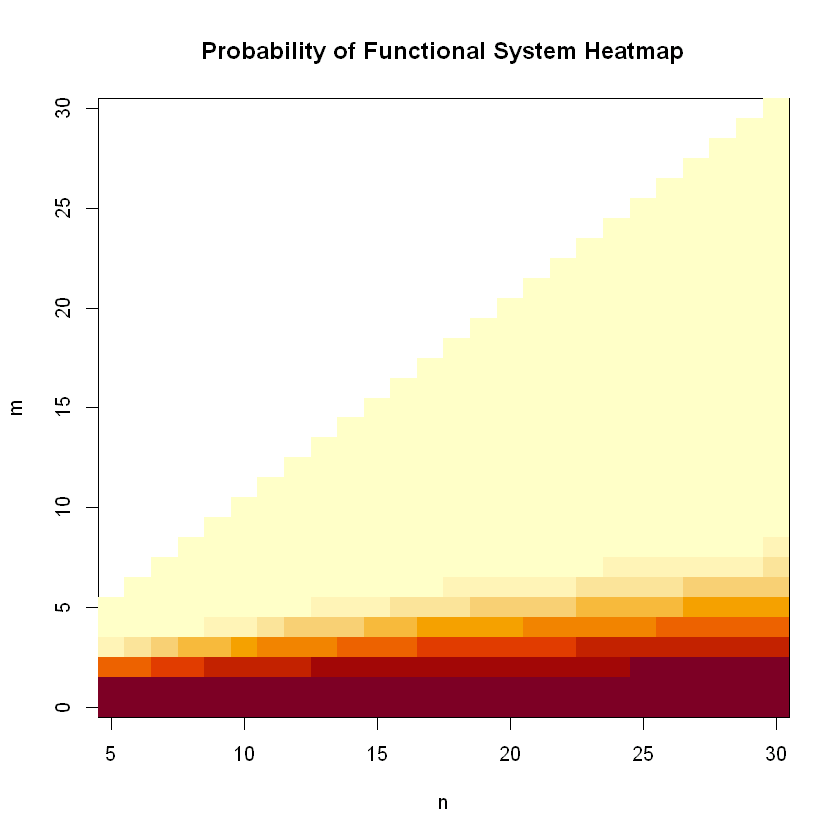

In [54]:
c_n <- 5:30
c_m <- 0:30

p <- matrix(
    NA,
    nrow = length(c_m),
    ncol = length(c_n)
)

for (i in seq_along(c_m)) {
    for (j in seq_along(c_n)) {
        n <- c_n[j]
        m <- c_m[i]
        if (m <= n) {
            p[i, j] <- functional_prob(n, m)
        }
    }
}

image(
    x = c_n,
    y = c_m,
    z = t(p),
    xlab = "n",
    ylab = "m",
    main = "Probability of Functional System Heatmap"
)

When $m > n - m + 1$, there is a threshold where $\Pr(\text{functional}) = 0$ because there are more defective antennas than gaps.

One trend is that $\Pr(\text{functional})$ decreases as $m$ increases because there are fewer ways to separate all defective antennas.

Another trend is that $\Pr(\text{functional})$ increases as $n$ increases because with more functional antennas, the defective antennas are increasingly unlikely to be next to one another. 

However as $m$ grows proportionally with $n$, the number of valid placements does not grow as quickly as the total number of placements, so $\Pr(\text{functional})$ decreases.


---
## Problem 8 — Reflection & Proof Sketches — 10 pts

1. Provide a proof sketch for the **binomial theorem** by induction **and** a combinatorial proof (term counting).
2. Explain the bijection behind **stars-and-bars** and how positivity vs. nonnegativity changes the count. Include a simple diagram (ASCII is fine).


## 1)

The binomial theorem states that $$(x + y)^n = \sum_{k = 0}^{n} \binom{n}{k}x^{n - k}y^k$$

### Proof by Induction

When $n=1$, $$(x + y)^1 = x + y$$ which satisfies the theorem.

Assuming the formula is true for some $n$, then $$ (x + y)^{n + 1} = (x + y) \sum_{k = 0}^{n} \binom{n}{k}x^{n - k}y^k$$

$$= x\sum_{k=0}^{n}\binom{n}{k}x^{n-k}y^k + y\sum_{k=0}^{n}\binom{n}{k}x^{n-k}y^k$$

$$= \sum_{k=0}^{n}\binom{n}{k}x^{n+1-k}y^k + \sum_{k=0}^{n}\binom{n}{k}x^{n-k}y^{k+1}$$

$$= \sum_{k=0}^{n}\binom{n}{k}x^{n+1-k}y^k + \sum_{k=1}^{n+1}\binom{n}{k-1}x^{n+1-k}y^k$$

$$= x^{n+1} + \sum_{k=1}^{n} \left(\binom{n}{k} + \binom{n}{k-1}\right) x^{n+1-k}y^k + y^{n+1}$$

Using Pascal's identity,

$$ \binom{n}{r}+\binom{n}{r-1} = \binom{n+1}{r}$$

$$(x + y)^{n + 1} = x^{n+1} + \sum_{k=1}^{n} \binom{n+1}{k} x^{n+1-k}y^k + y^{n+1}$$

Since $$x^{n+1} = \binom{n+1}{0}x^{n+1} \text{ and } y^{n+1} = \binom{n+1}{n+1}y^{n+1}$$

this means $$(x+y)^{n+1} = \sum_{k=0}^{n+1}\binom{n+1}{k}x^{n+1-k}y^k$$

The result holds for $n+1$. Therefore by induction it holds for all $n\geq 1$.

### Combinatorial Proof

Begin with $$(x+y)^n=(x+y)(x+y)\cdots(x+y)$$

which gives $$x^{n-k}y^k$$

We must choose $y$ from exactly $k$ of the $n$ factors and $x$ from the other $n - k$ factors, giving $$\binom{n}{k}$$

Therefore, the coefficient of $x^{n-k}y^k$ is $\binom{n}{k}$, giving $$(x+y)^n=\sum_{k=0}^{n}\binom{n}{k}x^{n-k}y^k$$

## 2)

For nonnegative integer solutions, represent the $n$ units by $n$ stars and use $r - 1$ bars to divide among the $r$ variables. For example,
$$
**|***|**
$$

corresponds to $$(x_1, x_2, x_3) = (2, 3, 2) $$

This is a bijection because every arrangement of $n$ stars and $r - 1$ bars produces exactly one solution by counting the stars in each section, and every solution is one arrangement. There are $n + r - 1$ total symbols and we choose where to place the $r - 1$ bars so the number of nonnegative solutions is $$\binom{n + r - 1}{r - 1}$$

so this is reversible. 

For positive integer solutions, each variable must receive at least one unit. Start giving one star to each variable first. If $$x_1+\cdots+x_r=n,\qquad x_i\ge 1$$

define $$y_i=x_i-1$$

then $$y_1+\cdots+y_r=n-r,\qquad y_i\ge 0$$

giving $$\binom{n-1}{r-1}$$

positive solutions.

For the nonnegative case, sections may be empty, while in the positive case, each section must contain at least one star.

For the example $n = 7$ and $r = 3$,

$$
|****|***
$$

is a valid non-negative solution but is not a valid positive solution.


---
## Implementation & Style Requirements (graded)

- **Reproducibility (5 pts):** fixed seed; no interactive input; all results recompute on “Restart & Run All”.
- **Numerical robustness (5 pts):** use `lgamma`/`gamma` or integer-safe products for large factorials; avoid overflow.
- **Testing (5 pts):** for each custom function, include at least 3 checks against known values.
- **Clarity (5 pts):** each problem starts with a Markdown plan/derivation, followed by code, and a brief interpretation.



---
## Submission Checklist

- File named `lastname_firstname_ch1_combinatorics.ipynb`
- Kernel is **R**
- Top cell includes `sessionInfo()` and `set.seed(631)`
- All figures render inline
- “Restart & Run All” completes without errors
